# Tema : Modelos ARIMA
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

## Ejercicio 1. Pronostico del PIB de Colombia.

- Usando los datos del Banco Mundial, estime un modelo ARIMA válido acorde a la teoría entre 1960-2024. Finalmente, realice el pronostico del PIB de Colombia para los próximos 5 años.



In [2]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')


# Descargar los datos del Banco Mundial

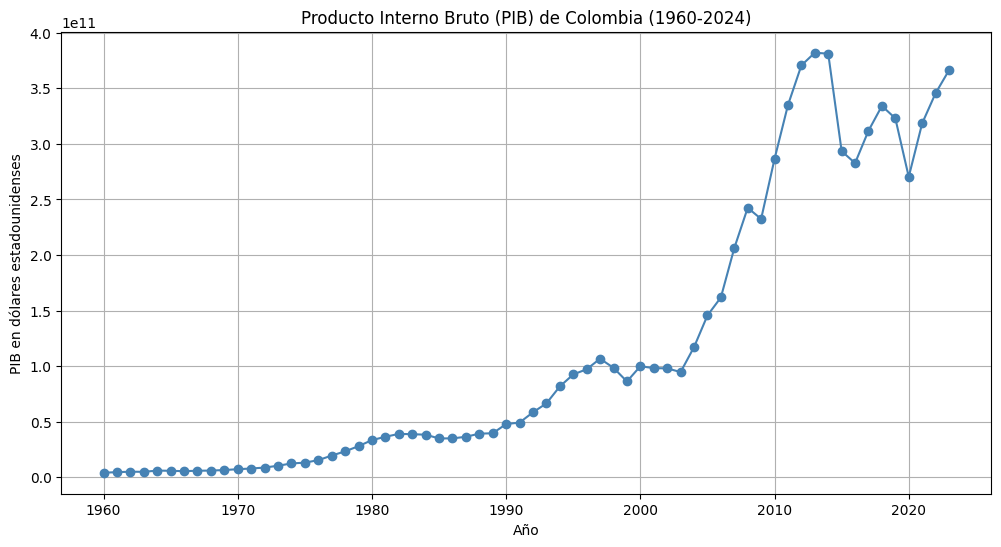

In [3]:
data = wb.data.DataFrame(series='NY.GDP.MKTP.CD', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data = data.set_index('year')
pib_col = data['pib']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, pib_col, marker='o', color='steelblue')
ax.set_title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
ax.set_xlabel('Año')
ax.set_ylabel('PIB en dólares estadounidenses')
ax.grid()
plt.show()


## Verificar estacionaridad de la serie original

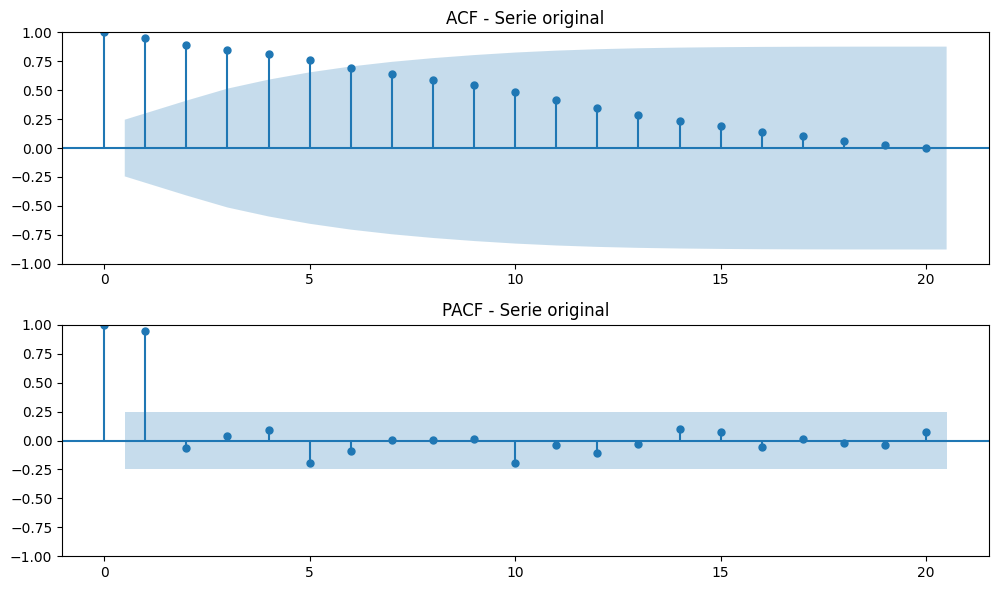

In [4]:
# Graficar la funcion de ACF y PACF
def graficar_autocorrelacion(data, title, maxlag = 20):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data, lags=maxlag, ax=axes[0], title=f'ACF - {title}')
    plot_pacf(data, lags=maxlag, ax=axes[1], title=f'PACF - {title}')
    plt.tight_layout()
    plt.show()

graficar_autocorrelacion(pib_col, title= "Serie original")

In [5]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    lb_test        = acorr_ljungbox(datos, lags=n_lags, return_df=True)
    min_p_value    = lb_test['lb_pvalue'].min()
    lb_stat        = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]

    # Durbin-Watson (Autocorrelación de primer orden)
    dw_stat = durbin_watson(datos)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4), round(lb_stat, 4)],
        'P-valor'     : [None, round(min_p_value, 4)]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if 1.5 < dw_stat < 2.5 else
        "Autocorrelación positiva" if dw_stat < 1.5 else
        "Autocorrelación negativa"
    )
    lb_conclu = "Sin autocorrelación" if min_p_value > 0.05 else "Autocorrelación detectada"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 80)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_autocorrelacion(pib_col, n_lags=20)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       0.0152      NaN   Autocorrelación positiva
1  Ljung-Box (hasta lag 20)     418.2162      0.0  Autocorrelación detectada


In [6]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(pib_col)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)       2.7717     1.00           No
1                           Prueba KPSS       0.9984     0.01           No


## Integración de la serie para estacionaridad

- Para integrar una serie con el fin de estabilizar la media y la varianza sacamos su primera diferencia

1. $E[Y_t] = \mu$ (constante) $\forall t$
2. $Var(Y_t) = \sigma^2$ (constante) $\forall t$
3. $Cov(Y_t, Y_{t+k}) = \gamma_k$ (solo depende del rezago $k$)

$$
\Delta y_t = y_t - y_{t-1}
$$

## Transformaciones usuales en las series económicas 

- Es usual transformar la series económicas en términos de crecimiento porcentual aplicando logaritmos y posterior tomar su primera diferencia que es equivalente a incremento porcentual.
- Como vimos en la transformación de Box-Cox (λ=0), el logaritmo ayuda a linealizar funciones exponenciales y varianza creciente.

$$
\Delta \log{y_t} = \log{y_t} - \log{y_{t-1}} = \log{\frac{y_t}{y_{t-1}}} \sim \%\Delta y_t
$$

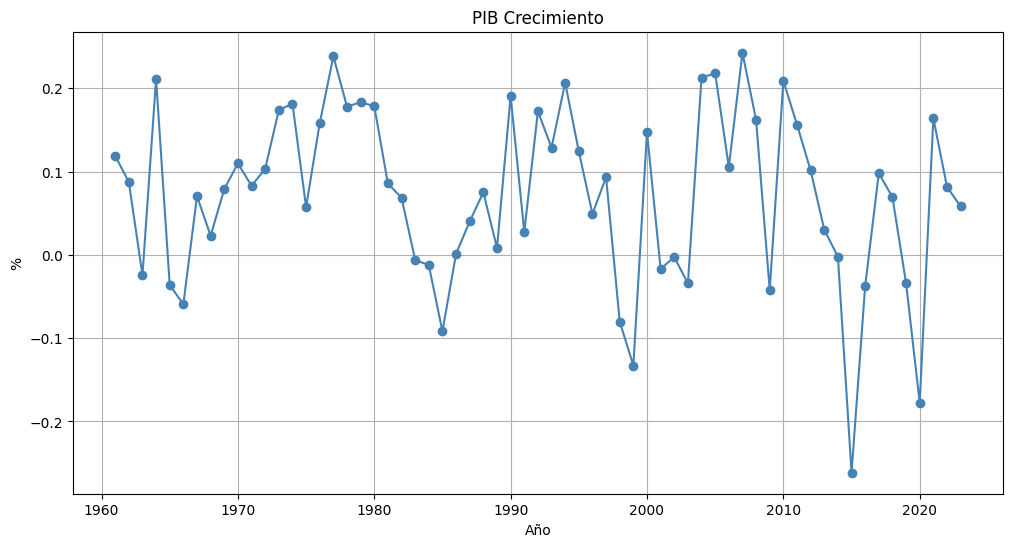

In [7]:
# Primera diferencia de la serie integrada de orden 1
pib_diff = pib_col.diff().dropna()

# Tomamos el logaritmo y la primera diferencia. Esto transforma la serie en tasas de crecimiento
pib_log = np.log(pib_col)
pib_crecimiento = pib_log.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_crecimiento, marker='o', color='steelblue')
ax.set_title('PIB Crecimiento')
ax.set_xlabel('Año')
ax.set_ylabel('%')
ax.grid()
plt.show()


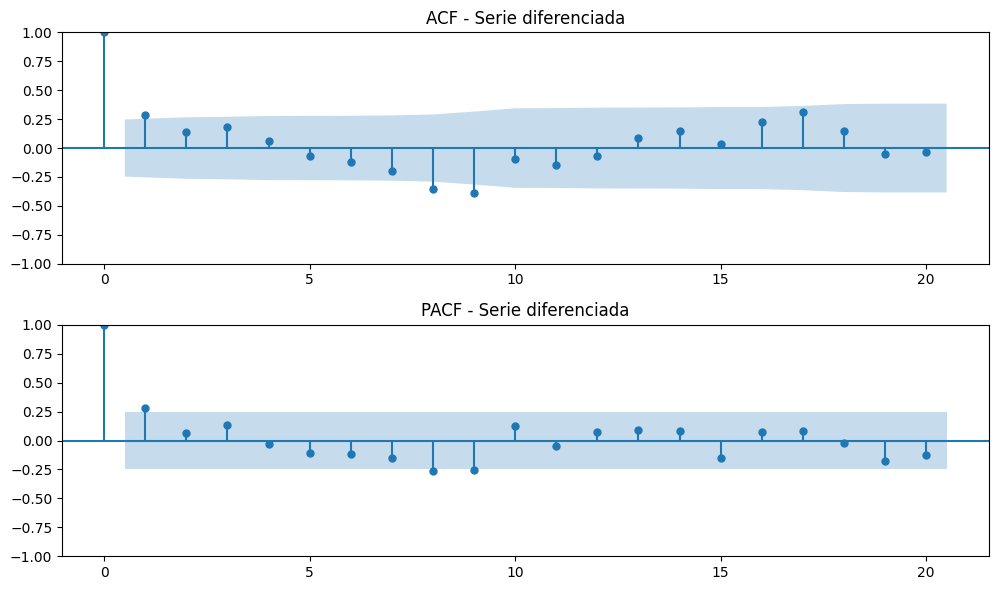

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -5.7998      0.0           Sí
1                           Prueba KPSS       0.1462      0.1           Sí


In [8]:
# Graficar la funcion de ACF y PACF de la serie diferenciada
graficar_autocorrelacion(pib_crecimiento, title="Serie diferenciada")

# Test estacionariedad
test_estacionariedad(pib_crecimiento)

## Estimación modelos ARIMA

In [9]:
# ARIMA(1, 1, 0)
m_arima110 = ARIMA(pib_crecimiento, order = (1, 0, 0), trend="n").fit()
print(m_arima110.summary())

# guardar modelos estimados
modelos = {}
modelos["ARIMA(1, 1, 0)"] = m_arima110

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  50.080
Date:                Sun, 01 Mar 2026   AIC                            -96.161
Time:                        12:17:34   BIC                            -91.874
Sample:                             0   HQIC                           -94.475
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5062      0.130      3.908      0.000       0.252       0.760
sigma2         0.0119      0.002      5.318      0.000       0.008       0.016
Ljung-Box (L1) (Q):                   3.37   Jarque-

In [10]:
# ARIMA(0, 1, 1)
m_arima011 = ARIMA(pib_crecimiento, order = (0, 0, 1), trend="n").fit()
print(m_arima011.summary())

# guardar
modelos["ARIMA(0, 1, 1)"] = m_arima011

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(0, 0, 1)   Log Likelihood                  47.260
Date:                Sun, 01 Mar 2026   AIC                            -90.520
Time:                        12:17:34   BIC                            -86.234
Sample:                             0   HQIC                           -88.835
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3965      0.146      2.710      0.007       0.110       0.683
sigma2         0.0130      0.003      4.937      0.000       0.008       0.018
Ljung-Box (L1) (Q):                   1.12   Jarque-

In [11]:
# ARIMA(1, 1, 1)
m_arima111 = ARIMA(pib_crecimiento, order = (1, 0, 1), trend="n").fit()
print(m_arima111.summary())

# guardar
modelos["ARIMA(1, 1, 1)"] = m_arima111

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  52.573
Date:                Sun, 01 Mar 2026   AIC                            -99.146
Time:                        12:17:34   BIC                            -92.717
Sample:                             0   HQIC                           -96.618
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8666      0.102      8.519      0.000       0.667       1.066
ma.L1         -0.5352      0.153     -3.507      0.000      -0.834      -0.236
sigma2         0.0109      0.002      5.407      0.0

In [12]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(modelos)

COMPARACIÓN DE MODELOS ARIMA
                 Modelo        AIC       AICc        BIC    Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                       
1        ARIMA(1, 1, 1) -99.146343 -98.739563 -92.716939  52.573171  0.011026  0.105003  0.084392       3   63
2        ARIMA(1, 1, 0) -96.160696 -95.960696 -91.874426  50.080348  0.011943  0.109285  0.085237       2   63
3        ARIMA(0, 1, 1) -90.520326 -90.320326 -86.234057  47.260163  0.013056  0.114265  0.091680       2   63
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): ARIMA(1, 1, 1)  →  AICc: -98.7395630684269


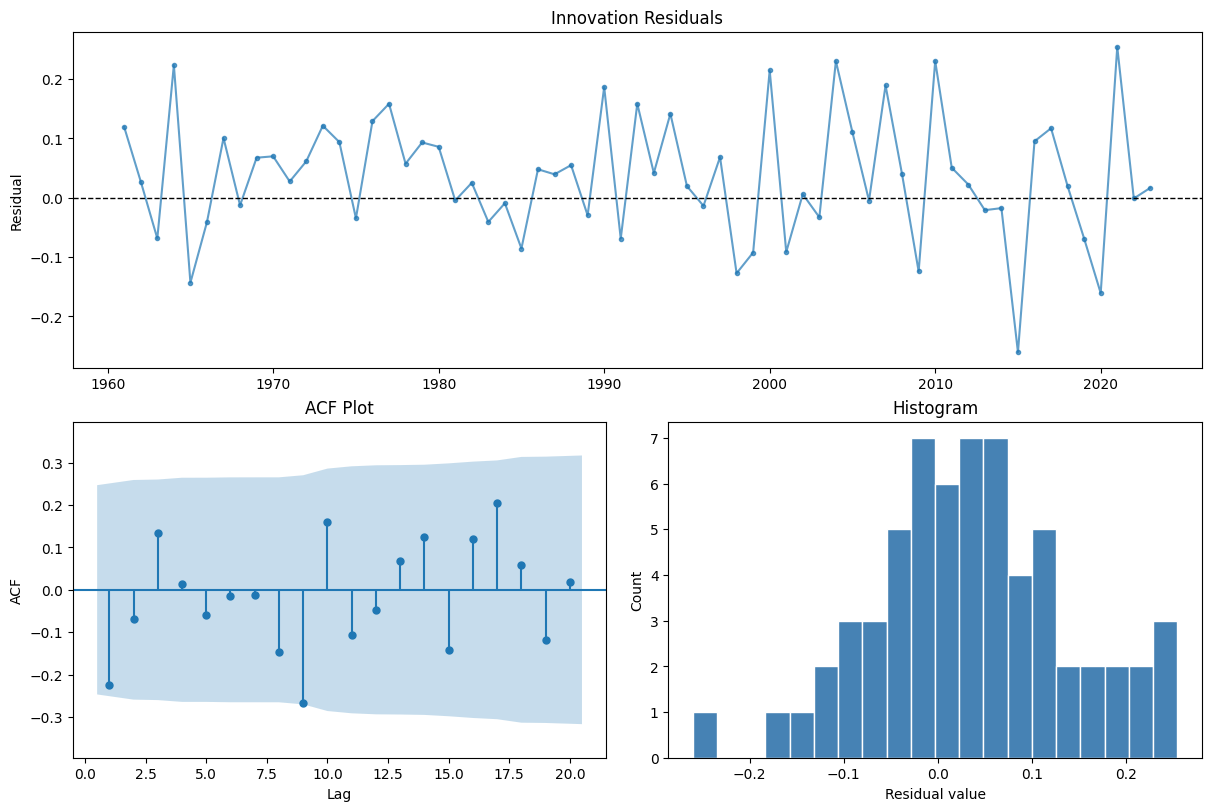

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       2.1778      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)       3.3523   0.0671  Sin autocorrelación


In [13]:
# Verificar ruido blanco
# Diagnostico del modelo
def plot_diagnostics(modelo, n_lags=None):
    if not "statsmodels" in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraemos residuos directamente del objeto de resultados
    resid = modelo.resid

    fig, axes = plt.subplot_mosaic(
        [["resid", "resid"], ["acf", "hist"]], 
        figsize=(12, 8), 
        constrained_layout=True
    )

    # Gráfico de Residuos
    ax = axes["resid"]
    ax.plot(resid, marker='.', linestyle='-', alpha=0.7)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set(title="Innovation Residuals", ylabel="Residual")

    # Gráfico ACF
    ax = axes["acf"]
    plot_acf(resid, ax=ax, zero=False, lags=n_lags, auto_ylims=True)
    ax.set(title="ACF Plot", xlabel="Lag", ylabel='ACF')

    # Histograma
    ax = axes["hist"]
    ax.hist(resid, bins=20, edgecolor='white', color='steelblue')
    ax.set(title="Histogram", xlabel="Residual value", ylabel="Count")
    
    plt.show()

    # test_autocorrelacion
    test_autocorrelacion(resid, n_lags=n_lags)

# Ejecución de la función
plot_diagnostics(modelo = modelos["ARIMA(1, 1, 0)"], n_lags=20)


In [24]:
# Auto-ARIMA encuentra los parámetros óptimos automáticamente
m_autoARIMA = auto_arima(pib_crecimiento, 
                         seasonal=False,      # No seasonal
                         stepwise=True,       # Búsqueda por pasos
                         trace=True,          # Mostrar progreso
                         error_action='ignore',
                         suppress_warnings=True,
                         max_p=5, max_q=5, d=None, trend="n") # No diferenciacion, por qué?

print("Auto-ARIMA")
print(m_autoARIMA.summary())
print(f'Parámetros óptimos: ARIMA{m_autoARIMA.order}')

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-95.508, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-79.573, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-96.161, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-90.520, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-96.649, Time=0.06 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-98.066, Time=0.08 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-96.221, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-96.190, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-97.191, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-94.273, Time=0.18 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-98.066, Time=0.04 sec

Best model:  ARIMA(3,0,0)(0,0,0)[0] intercept
Total fit time: 0.841 seconds
Auto-ARIMA
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  

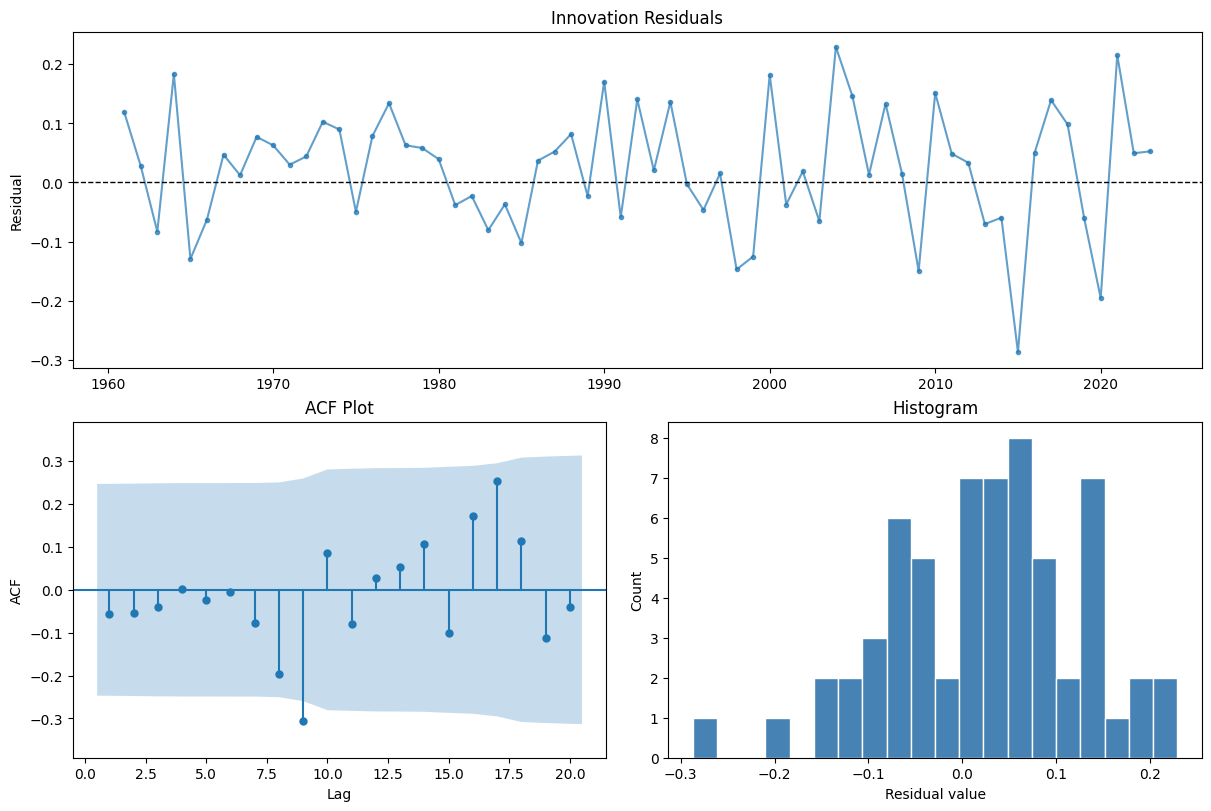

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       1.9954      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)      24.8246   0.1664  Sin autocorrelación


In [25]:
# Verificar ruido blanco
mejor_modelo = ARIMA(pib_crecimiento, order = (3, 0, 0), trend="n").fit()
plot_diagnostics(modelo = mejor_modelo, n_lags=20)

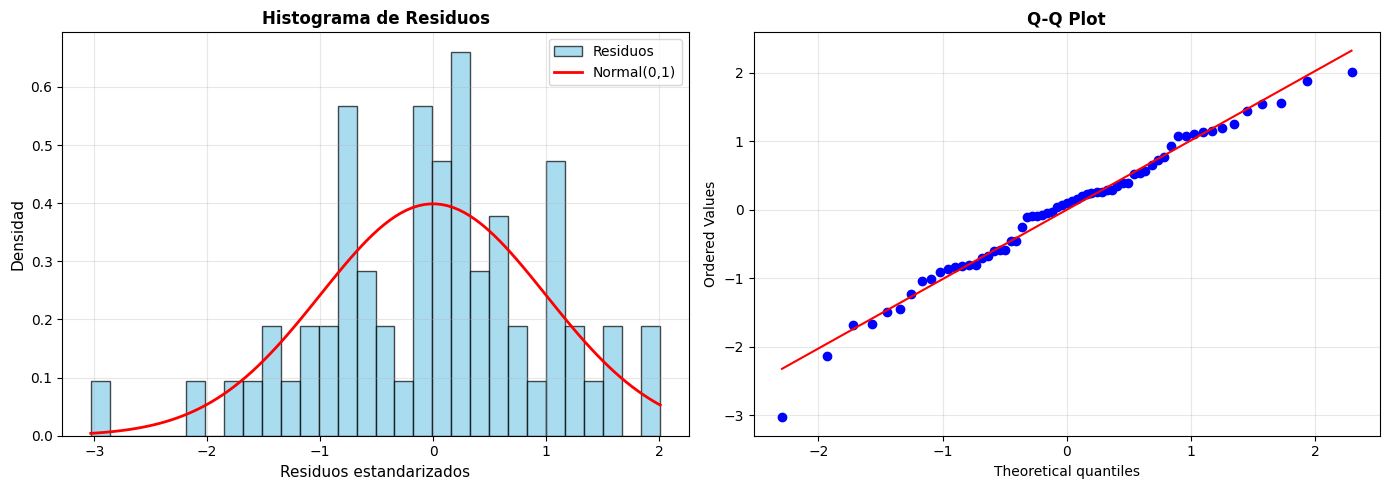

,test,estadistico,p_valor
0,Shapiro-Wilk,0.9839,0.5802
1,Jarque-Bera,1.7473,0.4174
2,Kolmogorov-Smirnov,0.0923,0.6230
3,Asimetría,-0.3897,NaN
4,Curtosis,3.2411,NaN


In [26]:
# Normalidad de los residuos
def check_normalidad(modelo):    
    # Verificación del tipo de modelo
    if 'statsmodels' not in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraer residuos estandarizados
    resid = modelo.resid
    resid_std = (resid - resid.mean()) / resid.std()
    
    # Gráfico 1: Histograma con curva normal
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1 = axes[0]
    ax1.hist(resid_std, bins=30, density=True, alpha=0.7, 
             color='skyblue', edgecolor='black', label='Residuos')
    
    # Superponer curva normal teórica
    x = np.linspace(resid_std.min(), resid_std.max(), 100)
    ax1.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, 
             label='Normal(0,1)')
    
    ax1.set_xlabel('Residuos estandarizados', fontsize=11)
    ax1.set_ylabel('Densidad', fontsize=11)
    ax1.set_title('Histograma de Residuos', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Q-Q Plot
    ax2 = axes[1]
    stats.probplot(resid_std, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Prueba de Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(resid)
    
    # Prueba de Jarque-Bera
    jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
    
    # Prueba de Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(resid_std, 'norm')
    
    # Resultados
    results = {
        'test' : ['Shapiro-Wilk', 'Jarque-Bera', 'Kolmogorov-Smirnov', 'Asimetría', 'Curtosis'],
        'estadistico' : [shapiro_stat, jb_stat, ks_stat, skew, kurtosis],
        'p_valor' : [shapiro_p, jb_p, ks_p, None, None]
    }
    tab_test = pd.DataFrame(results)
    tab_test[["estadistico", "p_valor"]] = tab_test[["estadistico", "p_valor"]].apply(lambda x: round(x, 4))
    return tab_test
    

check_normalidad(modelo = mejor_modelo)

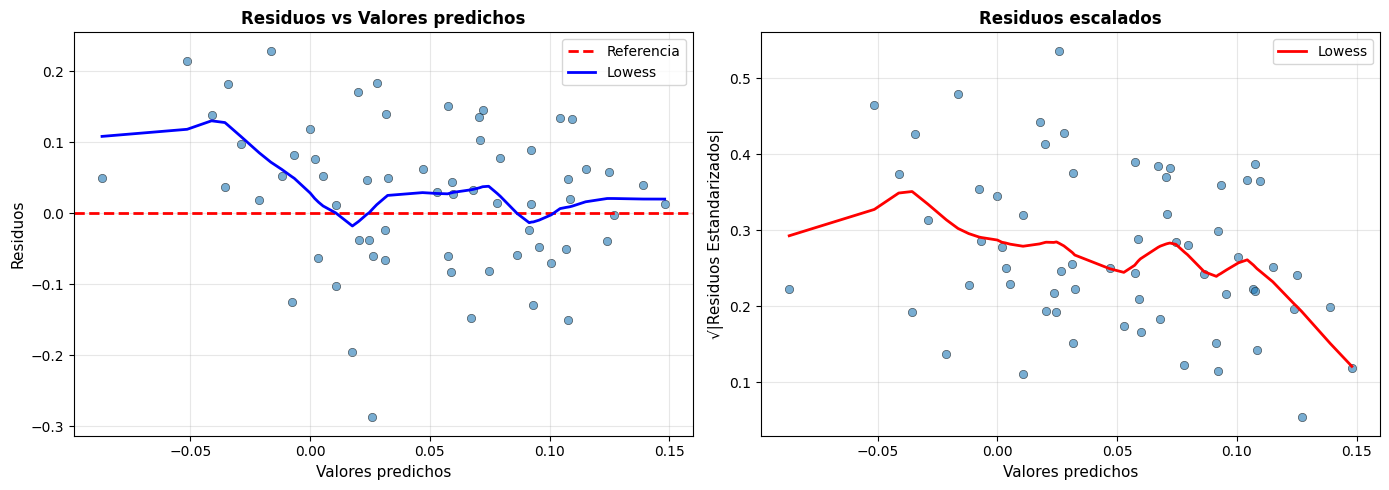

In [27]:
def check_homocedasticidad(modelo):
    # Verificación del tipo de modelo
    if 'statsmodels' not in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraer residuos y valores predichos del modelo
    resid = modelo.resid
    fitted_values = modelo.fittedvalues
    resid_abs = np.abs(resid)
    resid_sqrt = np.sqrt(resid_abs)
    
    # Crear figuras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Residuos vs Valores ajustados
    ax1 = axes[0]
    ax1.scatter(fitted_values, resid, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Referencia')
    
    # Línea de tendencia
    smoothed = lowess(resid, fitted_values, frac=0.3)
    ax1.plot(smoothed[:, 0], smoothed[:, 1], color='blue', linewidth=2, label='Lowess')
    
    ax1.set_xlabel('Valores predichos', fontsize=11)
    ax1.set_ylabel('Residuos', fontsize=11)
    ax1.set_title('Residuos vs Valores predichos', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Residuos Estandarizados
    ax2 = axes[1]
    ax2.scatter(fitted_values, resid_sqrt, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    # Línea de tendencia
    smoothed2 = lowess(resid_sqrt, fitted_values, frac=0.3)
    ax2.plot(smoothed2[:, 0], smoothed2[:, 1], color='red', linewidth=2, label='Lowess')
    
    ax2.set_xlabel('Valores predichos', fontsize=11)
    ax2.set_ylabel('√|Residuos Estandarizados|', fontsize=11)
    ax2.set_title('Residuos escalados', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

check_homocedasticidad(modelo=mejor_modelo)

## Pronóstico mejor modelo modelo crecimiento PIB

Acorde al DANE En 2024p, el Producto Interno Bruto (PIB) presenta un crecimiento de 1,5% respecto a 2023. El modelo pronosticó 0,67% de incremento para 2024 respecto a 2023.
https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/cuentas-nacionales-anuales

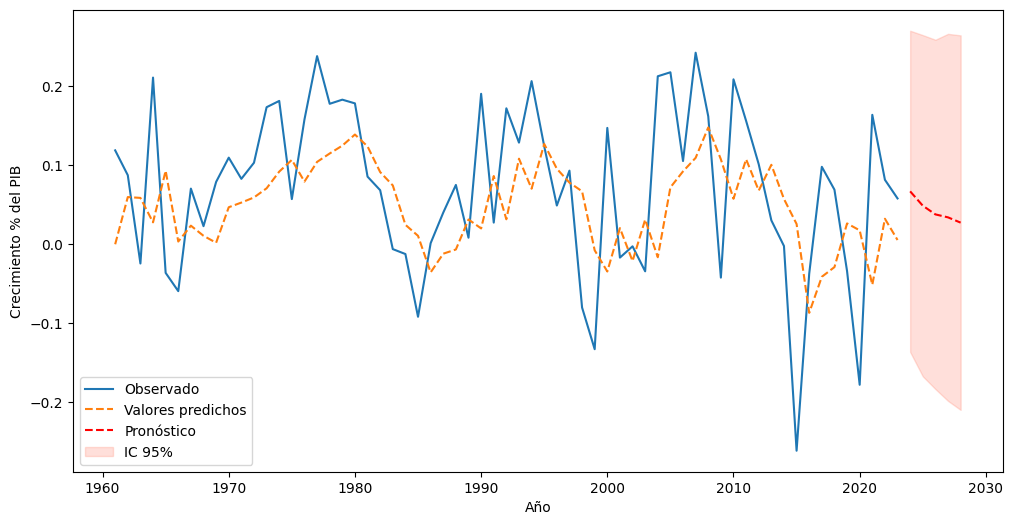

      Pronóstico  IC Inferior  IC Superior
Año                                       
2024    0.067046    -0.136455     0.270546
2025    0.048858    -0.167293     0.265010
2026    0.037849    -0.183422     0.259120
2027    0.034078    -0.198420     0.266576
2028    0.027394    -0.209859     0.264647


In [18]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_anio  = pib_crecimiento.index[-1]
anio_pronostico = range(ultimo_anio + 1, ultimo_anio + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_pib = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico_pib.predicted_mean
pred_ci = pronostico_pib.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = pib_crecimiento.plot(label = "Observado")
plt.plot(mejor_modelo.fittedvalues.index, mejor_modelo.fittedvalues, label = "Valores predichos", linestyle = "--")
pred_mean.plot(ax = ax, label = "Pronóstico", linestyle = "--", color = "red")
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('Crecimiento % del PIB')
ax.legend()
plt.show()

# Tabla de pronóstico 
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())


## Pronostico en sus niveles del PIB

- Reversar la transformación logarítmico del crecimiento
$$
\Delta \log(PIB_t) = \log(PIB_t) - \log(PIB_{t-1})  \\
PIB_{t+h} = PIB_{t} * \exp^{\sum^{h}_{i=1}\Delta \log(PIB_t)}
$$


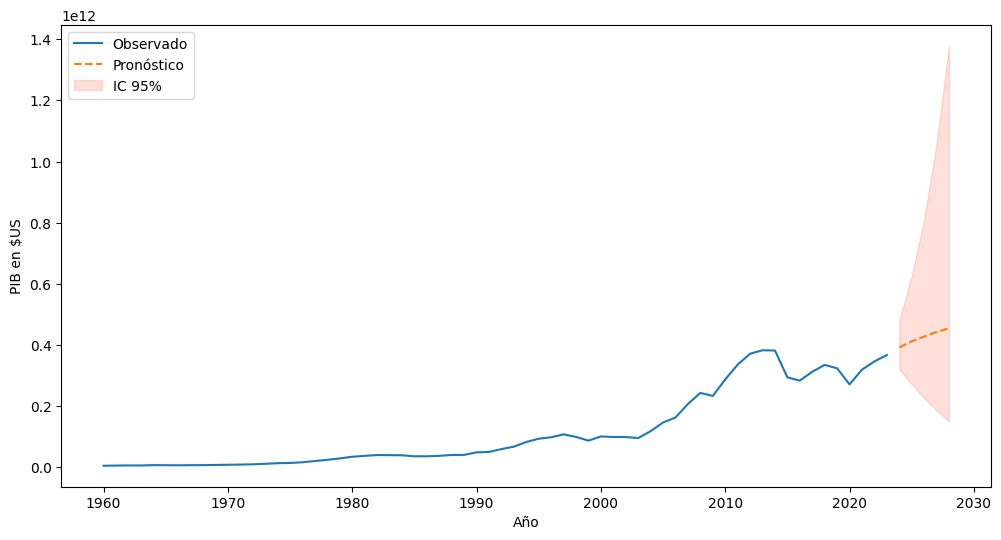

        Pronóstico   IC Inferior   IC Superior
Año                                           
2024  3.916920e+11  3.195698e+11  4.800913e+11
2025  4.113047e+11  2.703406e+11  6.257719e+11
2026  4.271705e+11  2.250360e+11  8.108683e+11
2027  4.419785e+11  1.845353e+11  1.058578e+12
2028  4.542535e+11  1.496026e+11  1.379296e+12


In [19]:
# Revertir log-diferencia a niveles
ultimo_pib_nivel = pib_col.iloc[-1]

pred_niveles     = ultimo_pib_nivel * np.exp(pred_mean.cumsum())
pred_ci_niveles  = pd.DataFrame({
    "lower": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 0].cumsum()),
    "upper": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 1].cumsum())
}, index=pred_mean.index)

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = pib_col.plot(label = "Observado")
pred_niveles.plot(ax = ax, label = "Pronóstico", linestyle = "--")
ax.fill_between(
    pred_ci_niveles.index,
    pred_ci_niveles["lower"],
    pred_ci_niveles["upper"],
    color="tomato", alpha=0.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('PIB en $US')
ax.legend()
plt.show()

# Tabla de pronóstico en niveles
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_niveles,
    "IC Inferior" : pred_ci_niveles["lower"],
    "IC Superior" : pred_ci_niveles["upper"],
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())
